In [73]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

from get_train_test import TrainTestBuilder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import brier_score_loss, roc_auc_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc, f1_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.calibration import calibration_curve


In [74]:
def split_red_blue_features(df: pd.DataFrame):
    """
    Splits the dataframe into red and blue sides with properly prefixed columns.
    Diff columns are given a red_ or blue_ prefix and negated for blue side.
    
    Only columns with 'red', 'blue', or 'diff' postfixes (plus allowed globals) 
    are included in the final output.

    Args:
        df (pd.DataFrame): Input dataframe with red, blue, and diff columns.

    Returns:
        red_df (pd.DataFrame)
        blue_df (pd.DataFrame)
        red_cols_final (list): final red columns
        blue_cols_final (list): final blue columns
    """
    
    allowed_globals = []  # include any global columns you want
    
    red_cols = [c for c in df.columns if "red" in c]
    blue_cols = [c for c in df.columns if "blue" in c]
    diff_cols = [c for c in df.columns if "diff" in c]

    # ---- Red DataFrame ----
    red_df = df[red_cols].copy()
    for c in diff_cols:
        base = c.replace("_diff", "")
        red_df[f"red_{base}_diff"] = df[c]
    # Include allowed global columns
    for col in allowed_globals:
        if col in df.columns:
            red_df[col] = df[col]

    # ---- Blue DataFrame ----
    blue_df = df[blue_cols].copy()
    for c in diff_cols:
        base = c.replace("_diff", "")
        blue_df[f"blue_{base}_diff"] = -df[c]  # negate diffs for blue
    
    for col in allowed_globals:
        if col in df.columns:
            blue_df[col] = df[col]

    # ---- Final column lists ----
    red_cols_final = [c for c in red_df.columns if c.endswith('_red')] + allowed_globals
    blue_cols_final = [c for c in blue_df.columns if c.endswith('_blue')] + allowed_globals

    # ---- Ensure only allowed columns exist ----
    red_df = red_df[red_cols_final]
    blue_df = blue_df[blue_cols_final]

    return red_df, blue_df, red_cols_final, blue_cols_final

def split_fav_dog(df: pd.DataFrame):

    fav_rows = []
    dog_rows = []
    df = df.reset_index(drop=True).copy()

    for _, row in df.iterrows():

        # -----------------------------------------
        # Identify favorite
        # -----------------------------------------
        red_fav = row["open_red"] <= row["open_blue"]   # ties → red fav
        blue_fav = row["open_blue"] < row["open_red"]

        # -----------------------------------------
        # Base fighter features
        # -----------------------------------------
        if red_fav:
            fav_row = {col.replace("red", "fav"): row[col] for col in row.index if "red" in col}
            dog_row = {col.replace("blue", "dog"): row[col] for col in row.index if "blue" in col}
        else:
            fav_row = {col.replace("blue", "fav"): row[col] for col in row.index if "blue" in col}
            dog_row = {col.replace("red", "dog"): row[col] for col in row.index if "red" in col}

        # -----------------------------------------
        # Fix diff_* properly
        # -----------------------------------------
        diff_row_fav = {}
        diff_row_dog = {}

        for col in row.index:
            if col.endswith("_diff"):
                base = col.replace("_diff", "")
                value = row[col]

                if red_fav:
                    diff_row_fav[f"fav_{base}_diff"] = value
                    diff_row_dog[f"dog_{base}_diff"] = -value
                else:
                    diff_row_fav[f"fav_{base}_diff"] = -value
                    diff_row_dog[f"dog_{base}_diff"] = value

        fav_row.update(diff_row_fav)
        dog_row.update(diff_row_dog)

        fav_rows.append(fav_row)
        dog_rows.append(dog_row)

    # ---------- Build DataFrames ----------
    fav_df = pd.DataFrame(fav_rows)
    dog_df = pd.DataFrame(dog_rows)

    # ---------- FINAL SAFETY CLEANUP ----------
    allowed_prefixes = ("fav_", "dog_")
    allowed_globals = []

    fav_df = fav_df[[c for c in fav_df.columns if c.endswith("_fav")]]
    dog_df = dog_df[[c for c in dog_df.columns if c.endswith("_dog")]]

    # -----------------------------------------
    # Winner label (fav = 1 if favorite wins)
    # -----------------------------------------
    y_fav_dog = []

    for _, row in df.iterrows():
        if row["open_red"] <= row["open_blue"]:  # red fav
            y_fav_dog.append(1 if row["winner"] == 1 else 0)
        else:
            y_fav_dog.append(1 if row["winner"] == 0 else 0)

    print(np.array(y_fav_dog).shape, df.shape)
    return fav_df, dog_df, np.array(y_fav_dog)





In [127]:
fp = r'C:\Users\jcmar\my_files\SportsBetting\data\entire_odds_stats_2025-12-04.csv'
df_model = pd.read_csv(fp)

df_model['math_red'] = df_model['math_red'].astype('category')
df_model['math_blue'] = df_model['math_blue'].astype('category')

non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'pimp_close1_blue','pimp_close1_red','pimp_close2_blue','pimp_close2_red',
    'juice_close1_blue','juice_close1_red','juice_close2_blue','juice_close2_red',
    'line_movement_close1_blue','line_movement_close1_red','line_movement_close2_blue','line_movement_close2_red',
    'winner_name',
    
    'red_fighter_odds','blue_fighter_odds',
    'dec_close1_blue','dec_close1_red','dec_close2_blue','dec_close2_red',
    'dec_fair_close1_blue','dec_fair_close1_red','dec_fair_close2_blue','dec_fair_close2_red',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'proba_fair_close1_red','proba_fair_close1_blue','proba_fair_close2_red','proba_fair_close2_blue',
    'performance_bonus_winner', 'fight_otn_bonus'
] #'close1_blue','close1_red', 'close2_blue', 'close2_red'

#'proba_fair_open_blue', 'proba_fair_open_red', 'juice_open_red', 'juice_open_blue',
selected_feats = [
        'open_blue','open_red', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',

       'juice_close1_blue', 'juice_close1_red', 'juice_close2_blue','juice_close2_red','juice_open_blue','juice_open_red',
        
       'months_since_diff', 
       'win_pct_red',
       'win_pct_blue', 'num_fights_diff',
        'wins_diff', 'losses_diff',
        'ko_wins_red', 'sub_wins_red','ko_wins_blue', 'sub_wins_blue','decision_wins_diff',
       
        'fav_counts_red','fav_counts_blue', 'dog_counts_blue', 'dog_counts_red',
        'line_movement_close1_blue','line_movement_close1_red','line_movement_close2_blue','line_movement_close2_red' ,

        'proba_fair_open_blue', 'proba_fair_open_red',
        'age_diff', 'reach_diff', 'event_age', 
        'sig_str_absorbed_total_diff', 'sig_str_absorbed_pm_diff', 'head_str_total_diff',
        'kd_total_diff', 'td_attempted_pm_diff','td_attempted_total_diff','ratio_td_blue','ratio_td_red',
        'max_elo_win_blue', 'max_elo_win_red','max_glicko_win_red', 'max_glicko_win_blue', 
        'td_defense_pct_blue', 'td_defense_pct_red', 'ratio_control_blue','ratio_control_red',
        'win_streak_diff','lose_streak_diff', 'weight_class', 'math_red', 'math_blue', 'total_bonus_diff']

# selected_feats = ['proba_fair_open_diff', 'age_diff', 'open_red', 'open_blue', 'reach_diff', 'sig_str_absorbed_total_diff', 
#                   'elo_red_proba', 'td_attempted_pm_diff', 'win_pct_diff', 'control_total_diff', 
#                   ]

selected_feats = ['proba_fair_open_red','proba_fair_open_blue', 'age_red', 'age_blue', 'sig_str_absorbed_total_red','sig_str_absorbed_total_blue','td_attempted_total_diff', 'ratio_td_diff',
                   'months_since_red', 'months_since_blue', 'dog_counts_red', 'dog_counts_blue', 'win_streak_red', 'win_streak_blue', 'lose_streak_red', 'lose_streak_blue',
                   'ko_losses_red', 'ko_losses_blue', 'td_landed_total_red', 'td_landed_total_blue','max_elo_win_red', 'sig_str_landed_total_red', 'sig_str_landed_total_blue',
                    'num_fights_blue', 'num_fights_red', 'age_diff',
                   'max_elo_win_blue', 'open_red', 'open_blue','reach_diff', 'womens_fight', 'win_pct_red', 'win_pct_blue', 'fighter_id']

gmm_cols = ['red_gmm_cluster', 'blue_gmm_cluster']

y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.8, random_state=42)
builder.filter_by_year(2010, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test = builder.prepare_train_test(selected_feats, clustering=False, one_hot_encode=False)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)


Filtered: kept 6577 rows from year 2010 onward.
PREPARE SHAPE: (4830, 290)
MODEL SHAPE: (4743, 290)
Categorical columns: ['womens_fight', 'red_id', 'blue_id']
Numerical columns: ['proba_fair_open_red', 'proba_fair_open_blue', 'age_red', 'age_blue', 'sig_str_absorbed_total_red', 'sig_str_absorbed_total_blue', 'td_attempted_total_diff', 'ratio_td_diff', 'months_since_red', 'months_since_blue', 'dog_counts_red', 'dog_counts_blue', 'win_streak_red', 'win_streak_blue', 'lose_streak_red', 'lose_streak_blue', 'ko_losses_red', 'ko_losses_blue', 'td_landed_total_red', 'td_landed_total_blue', 'max_elo_win_red', 'sig_str_landed_total_red', 'sig_str_landed_total_blue', 'num_fights_blue', 'num_fights_red', 'age_diff', 'max_elo_win_blue', 'open_red', 'open_blue', 'reach_diff', 'win_pct_red', 'win_pct_blue']


In [134]:
def build_train_test(X_train, X_test, y_train, y_test, open_close=True):
    red_train, blue_train, red_cols, blue_cols = split_red_blue_features(X_train)
    red_test, blue_test, _, _ = split_red_blue_features(X_test)

    # --- Split fav/dog features ---
    fav_train, dog_train, y_favdog_train = split_fav_dog(pd.concat([X_train, y_train], axis=1))
    fav_test, dog_test, y_favdog_test = split_fav_dog(pd.concat([X_test, y_test], axis=1))

    # --- Identify leftover columns not in red/blue/fav/dog ---
    assigned_train_cols = red_cols + blue_cols + list(fav_train.columns) + list(dog_train.columns)
    leftover_train = X_train[[c for c in X_train.columns if c not in assigned_train_cols]]
    leftover_test = X_test[[c for c in X_test.columns if c not in assigned_train_cols]]

    # --- Combine everything ---
    X_train_lr = pd.concat([
        red_train.reset_index(drop=True),
        blue_train.reset_index(drop=True),
        fav_train.reset_index(drop=True),
        dog_train.reset_index(drop=True),
        leftover_train.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)

    X_test_lr = pd.concat([
        red_test.reset_index(drop=True),
        blue_test.reset_index(drop=True),
        fav_test.reset_index(drop=True),
        dog_test.reset_index(drop=True),
        leftover_test.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)


    X_train_fav_dog = pd.concat([
        fav_train.reset_index(drop=True),
        dog_train.reset_index(drop=True),
        leftover_train.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)

    X_test_fav_dog = pd.concat([
        fav_test.reset_index(drop=True),
        dog_test.reset_index(drop=True),
        leftover_test.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)


    X_train_red_blue = pd.concat([
        red_train.reset_index(drop=True),
        blue_train.reset_index(drop=True),
        leftover_train.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)


    X_test_red_blue = pd.concat([
        red_test.reset_index(drop=True),
        blue_test.reset_index(drop=True),
        leftover_test.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)

    if open_close is False:
        X_train_red_blue = X_train_red_blue.drop(columns=['open_red', 'open_blue'])
        X_test_red_blue = X_test_red_blue.drop(columns=['open_red', 'open_blue'])
        X_train_fav_dog = X_train_fav_dog.drop(columns=['open_fav', 'open_dog'])
        X_test_fav_dog = X_test_fav_dog.drop(columns=['open_fav', 'open_dog'])

    X_train_fav_dog = X_train_fav_dog[X_test_fav_dog.columns]

    return X_train_lr, X_test_lr, X_train_fav_dog, X_test_fav_dog, X_train_red_blue, X_test_red_blue, y_favdog_train, y_favdog_test

_, _, X_train_fav_dog, X_test_fav_dog, X_train_red_blue, X_test_red_blue, y_favdog_train, y_favdog_test = build_train_test(X_train, X_test, y_train, y_test, open_close=False)


(3794,) (3794, 36)
(949,) (949, 36)


In [68]:
from catboost import CatBoostClassifier
from sklearn.metrics import brier_score_loss
from catboost.utils import get_gpu_device_count
from catboost import Pool
print(get_gpu_device_count())

1


In [ ]:
# Example: define your categorical columns
# Only include actual categorical features, not continuous numeric features
cat_features = ['womens_fight', 'red_id', 'blue_id']  
# Make sure these columns are string or int
for col in cat_features:
    X_train_fav_dog[col] = X_train_fav_dog[col].astype(float).astype(int)
    X_test_fav_dog[col]  = X_test_fav_dog[col].astype(float).astype(int)


y_favdog_train, y_favdog_test
# Compute scale_pos_weight for imbalanced classes
scale_pos_weight = (len(y_favdog_train) - y_favdog_train.sum()) / y_favdog_train.sum()
print("Scale pos weight:", scale_pos_weight)

# Create Pool objects for training and testing
train_pool = Pool(data=X_train_fav_dog, label=y_favdog_train, cat_features=cat_features)
test_pool  = Pool(data=X_test_fav_dog, label=y_favdog_test, cat_features=cat_features)

# Initialize CatBoost model
model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.02,
    depth=4,
    task_type='GPU',
    devices='0',
    scale_pos_weight=scale_pos_weight,

    # GPU-compatible anti-overfitting settings
    bootstrap_type='Bernoulli',
    subsample=0.8,
    l2_leaf_reg=5,
    random_strength=1.0,
    min_data_in_leaf=20,
    border_count=128,

    # overfitting detector
    od_type='Iter',
    od_wait=9000,

    eval_metric='F1',
    verbose=100
)

# Train the model using Pool objects
model.fit(train_pool, eval_set=test_pool)

# Make predictions
y_pred = model.predict(test_pool)
y_pred_train = model.predict(train_pool)

# Probabilities
y_pred_proba = model.predict_proba(test_pool)[:,1]
y_pred_proba_train = model.predict_proba(train_pool)[:,1]

# Evaluate accuracy
acc_test = accuracy_score(y_favdog_test, y_pred)
acc_train = accuracy_score(y_favdog_train, y_pred_train)
print(f"Train Accuracy: {acc_train:.4f}")
print(f"Test Accuracy: {acc_test:.4f}")

# Evaluate Brier score
brier_test = brier_score_loss(y_favdog_test, y_pred_proba)
brier_train = brier_score_loss(y_favdog_train, y_pred_proba_train)
print(f"Train Brier Score: {brier_train:.4f}")
print(f"Test Brier Score: {brier_test:.4f}")

Scale pos weight: 0.5894428152492669
0:	learn: 0.5222416	test: 0.5300994	best: 0.5300994 (0)	total: 45.8ms	remaining: 1m 8s
100:	learn: 0.6214031	test: 0.6147761	best: 0.6221807 (95)	total: 2.17s	remaining: 30.1s
200:	learn: 0.6502588	test: 0.6158332	best: 0.6221807 (95)	total: 4.27s	remaining: 27.6s
300:	learn: 0.6686870	test: 0.6211596	best: 0.6221807 (95)	total: 6.36s	remaining: 25.4s
400:	learn: 0.6844971	test: 0.6179200	best: 0.6221807 (95)	total: 8.46s	remaining: 23.2s
500:	learn: 0.6967116	test: 0.6210993	best: 0.6221807 (95)	total: 10.5s	remaining: 20.9s
600:	learn: 0.7027499	test: 0.6247465	best: 0.6249863 (599)	total: 12.4s	remaining: 18.6s
700:	learn: 0.7162071	test: 0.6297364	best: 0.6318176 (689)	total: 14.4s	remaining: 16.4s
800:	learn: 0.7274632	test: 0.6266028	best: 0.6318176 (689)	total: 16.3s	remaining: 14.2s
900:	learn: 0.7403267	test: 0.6229656	best: 0.6318176 (689)	total: 18.3s	remaining: 12.1s
1000:	learn: 0.7485627	test: 0.6276489	best: 0.6318176 (689)	total: 20.

In [137]:
train_pool = Pool(
    data=X_train_fav_dog,
    label=y_favdog_train,
    cat_features=cat_features
)

# Feature importance
feature_importances = model.get_feature_importance(train_pool)

fi_df = pd.DataFrame({
    'feature': X_train_fav_dog.columns,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

print(fi_df)

                       feature  importance
31                      red_id    6.724131
7                ko_losses_fav    6.645545
32                     blue_id    6.440023
13         proba_fair_open_dog    6.261435
0          proba_fair_open_fav    5.751522
19             lose_streak_dog    5.328116
8          td_landed_total_fav    5.312123
14                     age_dog    5.147049
22             max_elo_win_dog    3.956318
16            months_since_dog    3.821345
11             max_elo_win_fav    3.393375
5               win_streak_fav    3.282512
17              dog_counts_dog    2.865965
1                      age_fav    2.746284
26     td_attempted_total_diff    2.743493
2   sig_str_absorbed_total_fav    2.700225
15  sig_str_absorbed_total_dog    2.683433
3             months_since_fav    2.364970
6              lose_streak_fav    2.285636
28                    age_diff    2.168948
21         td_landed_total_dog    2.099990
29                  reach_diff    1.833177
12         

In [ ]:
df_logit_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\test_logit_open.csv')
df_logit_train_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\train_logit_open.csv')

logit_red_proba_test = df_logit_test_open['proba_red']
logit_blue_proba_test = df_logit_test_open['proba_blue']

logit_red_proba_train = df_logit_train_open['proba_red']
logit_blue_proba_train = df_logit_train_open['proba_blue']

cb_red_proba_train = y_pred_proba_train
cb_red_proba_test = y_pred_proba

cb_blue_proba_test = 1-y_pred_proba
cb_blue_proba_train = 1-y_pred_proba_train

X_train = np.column_stack([logit_red_proba_train, logit_blue_proba_train, cb_blue_proba_train, cb_red_proba_train])
X_test = np.column_stack([logit_red_proba_test, logit_blue_proba_test, cb_blue_proba_test, cb_red_proba_test])

In [86]:
X_train = np.column_stack([logit_red_proba_train, logit_blue_proba_train, cb_blue_proba_train, cb_red_proba_train])
X_test = np.column_stack([logit_red_proba_test, logit_blue_proba_test, cb_blue_proba_test, cb_red_proba_test])

In [91]:
y = y_train  


meta_model = LogisticRegression()
meta_model.fit(X_train, y_train)

# Make predictions
y_meta_pred_test = meta_model.predict(X_test)
y_meta_predd_train = meta_model.predict(X_train)

y_meta_proba = meta_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_meta_pred_test))
print("Brier Score:", brier_score_loss(y_test, y_meta_proba))

Accuracy: 0.59536354056902
Brier Score: 0.2725331851102291


In [96]:
# Predictions
y_train_pred = meta_model.predict(X_train)
y_test_pred = meta_model.predict(X_test)

y_meta_proba_test = meta_model.predict_proba(X_test)[:, 1]
y_meta_proba_train = meta_model.predict_proba(X_train)[:, 1]


# Train accuracy
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_acc:.4f}")

# Test accuracy
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.8258
Test Accuracy: 0.5954


In [89]:
from sklearn.isotonic import IsotonicRegression


In [90]:
def calibrate_statsmodels_logit(
        raw_train, raw_test, y_train, y_test,
        method="platt",
        bins=10,
        figsize=(14,5)
    ):
    """
    Calibrate a statsmodels Logit model using Platt scaling or Isotonic regression.
    Produces side-by-side calibration plots for train and test sets.

    Returns dictionary with calibrated probabilities and metrics.
    """

    raw_train = np.asarray(raw_train)
    raw_test = np.asarray(raw_test)

    # ---- Fit Calibration Model ----
    if method == "platt":
        calib_model = LogisticRegression(solver='lbfgs')
        calib_model.fit(raw_train.reshape(-1,1), y_train)

        cal_train = calib_model.predict_proba(raw_train.reshape(-1,1))[:,1]
        cal_test  = calib_model.predict_proba(raw_test.reshape(-1,1))[:,1]

    elif method == "isotonic":
        calib_model = IsotonicRegression(out_of_bounds="clip")
        calib_model.fit(raw_train, y_train)

        cal_train = calib_model.predict(raw_train)
        cal_test  = calib_model.predict(raw_test)

    else:
        raise ValueError("Method must be 'platt' or 'isotonic'")

    # ---- Metrics ----
    def compute_metrics(y_true, probs, bins=10):
        # Accuracy
        acc = accuracy_score(y_true, (probs >= 0.5).astype(int))

        # Brier score
        brier = brier_score_loss(y_true, probs)

        # Calibration curve (quantile bins)
        prob_true, prob_pred = calibration_curve(
            y_true, probs, n_bins=bins, strategy="quantile"
        )

        # ECE: each quantile bin contains equal number of samples
        K = len(prob_true)
        weights = np.ones(K) / K
        ece = np.sum(np.abs(prob_true - prob_pred) * weights)

        return acc, brier, ece, prob_true, prob_pred

    acc_tr, brier_tr, ece_tr, pt_tr, pp_tr = compute_metrics(y_train, cal_train, bins)
    acc_te, brier_te, ece_te, pt_te, pp_te = compute_metrics(y_test, cal_test, bins)

    # ---- Plot side-by-side calibration curves ----
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # TRAIN PLOT
    axes[0].plot(pp_tr, pt_tr, marker='o', label='Train Calibrated')
    axes[0].plot([0,1], [0,1], '--', color='black')
    axes[0].set_title(
        f"Train Calibration\nAcc={acc_tr:.5f} | Brier={brier_tr:.5f} | ECE={ece_tr:.6f}"
    )
    axes[0].set_xlabel("Predicted Probability")
    axes[0].set_ylabel("Observed Frequency")
    axes[0].grid(alpha=0.3)

    # TEST PLOT
    axes[1].plot(pp_te, pt_te, marker='o', label='Test Calibrated', color='orange')
    axes[1].plot([0,1], [0,1], '--', color='black')
    axes[1].set_title(
        f"Test Calibration\nAcc={acc_te:.5f} | Brier={brier_te:.5f} | ECE={ece_te:.6f}"
    )
    axes[1].set_xlabel("Predicted Probability")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "raw_train": raw_train,
        "raw_test": raw_test,
        "calibrated_train": cal_train,
        "calibrated_test": cal_test,
        "calibration_model": calib_model,
        "train_metrics": {
            "accuracy": acc_tr, "brier": brier_tr, "ece": ece_tr,
            "prob_true": pt_tr, "prob_pred": pp_tr
        },
        "test_metrics": {
            "accuracy": acc_te, "brier": brier_te, "ece": ece_te,
            "prob_true": pt_te, "prob_pred": pp_te
        }
    }

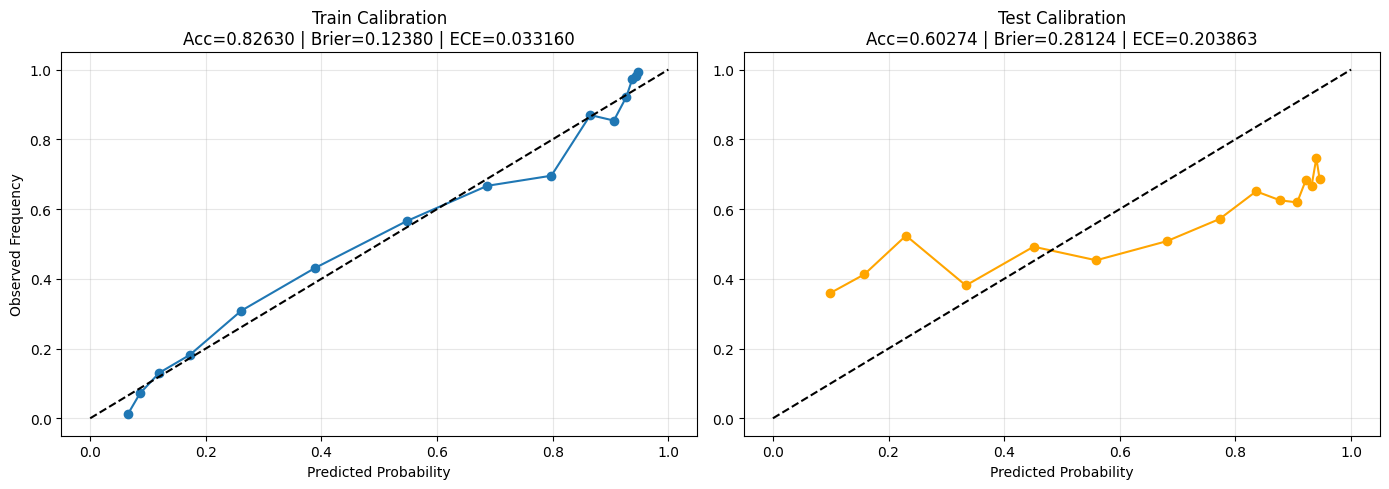

In [98]:
results = calibrate_statsmodels_logit(y_meta_proba_train, y_meta_proba_test, y_train, y_test, method='platt', bins=15)

In [100]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, models ,regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, BatchNormalization, Dense, Activation, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, ELU
from tensorflow.keras.activations import gelu
from itertools import combinations


In [115]:
def build_full_combination_pyramid(input_dim_red, input_dim_blue, input_dim_fav, input_dim_dog, dropout_rate=0.2):
    # --- Individual subnetworks ---
    def shallow_subnet(input_dim, name_prefix):
        inp = Input(shape=(input_dim,), name=f"{name_prefix}_input")
        x = layers.Dense(16)(inp)
        x = layers.BatchNormalization(momentum=0.96)(x)
        # x = layers.Activation("relu")(x)
        x = layers.ELU(alpha=.3)(x)
        x = layers.Dropout(dropout_rate)(x)
        return inp, x

    # Create subnetworks
    red_input, red_feat = shallow_subnet(input_dim_red, "red")
    blue_input, blue_feat = shallow_subnet(input_dim_blue, "blue")
    fav_input, fav_feat = shallow_subnet(input_dim_fav, "fav")
    dog_input, dog_feat = shallow_subnet(input_dim_dog, "dog")

    features = {
        "red": red_feat,
        "blue": blue_feat,
        "fav": fav_feat,
        "dog": dog_feat
    }

    # --- All pairwise concatenations ---
    concat_features = {}
    for a, b in combinations(features.keys(), 2):
        concat = layers.Concatenate(name=f"{a}_{b}_concat")([features[a], features[b]])

        # concat = layers.Dense(128)(concat)
        # concat = layers.BatchNormalization(momentum=0.96)(concat)
        # # concat = layers.ELU(alpha=0.3)(concat)
        # concat = layers.Activation("relu")(concat)
        # concat = layers.Dropout(dropout_rate)(concat)

        concat = layers.Dense(32)(concat)
        concat = layers.BatchNormalization(momentum=0.95)(concat)
        concat = layers.ELU(alpha=.32)(concat)
        concat = layers.Dropout(dropout_rate)(concat)

        concat_features[f"{a}_{b}"] = concat

    # --- Final concatenation of all pairwise combinations ---
    all_concat = layers.Concatenate(name="final_concat")(
        list(concat_features.values())
    )

    # all_concat = layers.Dense(128)(all_concat)
    # all_concat = layers.BatchNormalization(momentum=0.9)(all_concat)
    # all_concat = layers.ELU(alpha=0.3)(all_concat)
    # all_concat = layers.Dropout(dropout_rate)(all_concat)

    # all_concat = layers.Dense(64)(all_concat)
    # all_concat = layers.BatchNormalization(momentum=0.92)(all_concat)
    # # all_concat = layers.ELU(alpha=0.3)(all_concat)
    # all_concat = layers.Activation("relu")(all_concat)
    # all_concat = layers.Dropout(dropout_rate)(all_concat)

    all_concat = layers.Dense(8)(all_concat)
    all_concat = layers.BatchNormalization(momentum=0.92)(all_concat)
    all_concat = layers.ELU(alpha=0.3)(all_concat)
    # all_concat = layers.Activation("relu")(all_concat)
    all_concat = layers.Dropout(dropout_rate)(all_concat)

    # all_concat = layers.Dense(16)(all_concat)
    # all_concat = layers.BatchNormalization(momentum=0.92)(all_concat)
    # # all_concat = layers.ELU(alpha=0.3)(all_concat)
    # all_concat = layers.Activation("relu")(all_concat)
    # all_concat = layers.Dropout(dropout_rate)(all_concat)


    output = layers.Dense(1, activation="sigmoid", name="final_output")(all_concat)

    # Model
    model = Model(
        inputs=[red_input, blue_input, fav_input, dog_input],
        outputs=[output] 
    )
    
    return model

In [116]:
red_train, blue_train, red_cols, blue_cols = split_red_blue_features(X_train)
red_test, blue_test, _, _ = split_red_blue_features(X_test)

fav_train, dog_train, y_favdog_train = split_fav_dog(pd.concat([X_train, y_train],axis=1, ignore_index=False))
fav_test, dog_test, y_favdog_test = split_fav_dog(pd.concat([X_test, y_test],axis=1, ignore_index=False))


(3794,) (3794, 36)
(949,) (949, 36)


In [117]:
model = build_full_combination_pyramid(
    input_dim_red=red_train.shape[1],
    input_dim_blue=blue_train.shape[1],
    input_dim_fav=fav_train.shape[1],
    input_dim_dog=dog_train.shape[1]
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.7,
    patience=10,
    min_lr=1e-6
)

def brier_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
    return tf.reduce_mean(tf.square(y_pred - y_true))

model.compile(
    optimizer=tf.keras.optimizers.Adam(.0001),
    loss=brier_loss,
    metrics=["accuracy"]
)
# full_train_acc_callback = FullTrainAccuracyCallback([fav_train, dog_train], y_favdog_train)

history = model.fit(
    [red_train, blue_train, fav_train, dog_train], y_train,
    validation_data=([red_test, blue_test, fav_test, dog_test], y_test),
    epochs=100,
    batch_size=128,
    verbose=1,
    callbacks=[reduce_lr]
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5345 - loss: 0.2772 - val_accuracy: 0.5427 - val_loss: 0.2621 - learning_rate: 1.0000e-04
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5469 - loss: 0.2669 - val_accuracy: 0.5616 - val_loss: 0.2517 - learning_rate: 1.0000e-04
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5390 - loss: 0.2618 - val_accuracy: 0.5806 - val_loss: 0.2421 - learning_rate: 1.0000e-04
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5760 - loss: 0.2524 - val_accuracy: 0.6048 - val_loss: 0.2344 - learning_rate: 1.0000e-04
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5729 - loss: 0.2539 - val_accuracy: 0.6217 - val_loss: 0.2289 - learning_rate: 1.0000e-04
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5828 - loss: 0.2497 - val_accuracy: 0.6291 - val_loss: 0.2252 - learning_rate: 1.0000e-04
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5663